In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from src.config import EVENTS, SENSORS
from src.preprocessor import load_and_normalize, print_normalization_stats
from src.features import extract_features

Path("../outputs/figures").mkdir(parents=True, exist_ok=True)
Path("../outputs/models").mkdir(parents=True, exist_ok=True)

In [2]:
PROCESSED_PATH = "../outputs/processed_data.parquet"

if Path(PROCESSED_PATH).exists():
    print("Loading saved data...")
    df_norm = pd.read_parquet(PROCESSED_PATH)
    print(f"Rows loaded: {len(df_norm):,}")
else:
    print("File not found, attempting again...")
    df_norm, scaler = load_and_normalize(
        max_files_per_event=10,
        min_sensors=2,
        fit_scaler=True,
        scaler_path="../outputs/models/scaler.pkl",
    )
    df_norm.to_parquet(PROCESSED_PATH, index=False)

Loading saved data...
Rows loaded: 3,653,142


In [3]:
from src.features import extract_features

print("Extracting features from dataframes...")
df_features = extract_features(df_norm)

print(f"\nLabel balance:")
print(df_features["label"].value_counts())

print(f"\nBy event type:")
for eid, cnt in df_features["event_type"].value_counts().items():
    print(f"  {eid} {EVENTS[eid]:<20}: {cnt:>6,} окон")

print(f"\nFirst features:")
feature_cols = [c for c in df_features.columns if c not in ("label", "event_type")]
df_features[feature_cols[:6]].head(3).round(3)

Extracting features from dataframes...
Dataframes extracted: 121,696
Signs: 31

Label balance:
label
1    91086
0    30610
Name: count, dtype: int64

By event type:
  7 Scaling PCK         : 91,291 окон
  9 Hydrate             : 12,654 окон
  0 Normal              :  7,139 окон
  3 DHSV Failure        :  7,039 окон
  4 Severe Slugging     :  3,573 окон

First features:


,source,T-TPT_mean,T-TPT_std,T-TPT_min,T-TPT_max,T-TPT_range
0,WELL-00001_20170201010207.parquet,0.878,0.0,0.878,0.878,0.0
1,WELL-00001_20170201010207.parquet,0.878,0.0,0.878,0.878,0.0
2,WELL-00001_20170201010207.parquet,0.878,0.0,0.878,0.878,0.0


In [4]:
feature_cols = [c for c in df_features.columns if c not in ("label", "event_type")]

all_zero = (df_features[feature_cols] == 0).all(axis=1).sum()
print(f"Fully zero rows: {all_zero} ({all_zero/len(df_features)*100:.1f}%)")

nan_pct = df_features[feature_cols].isnull().mean() * 100
print("\nSkips in signs (%):")
print(nan_pct[nan_pct > 0].sort_values(ascending=False))

Fully zero rows: 0 (0.0%)

Skips in signs (%):
Series([], dtype: float64)


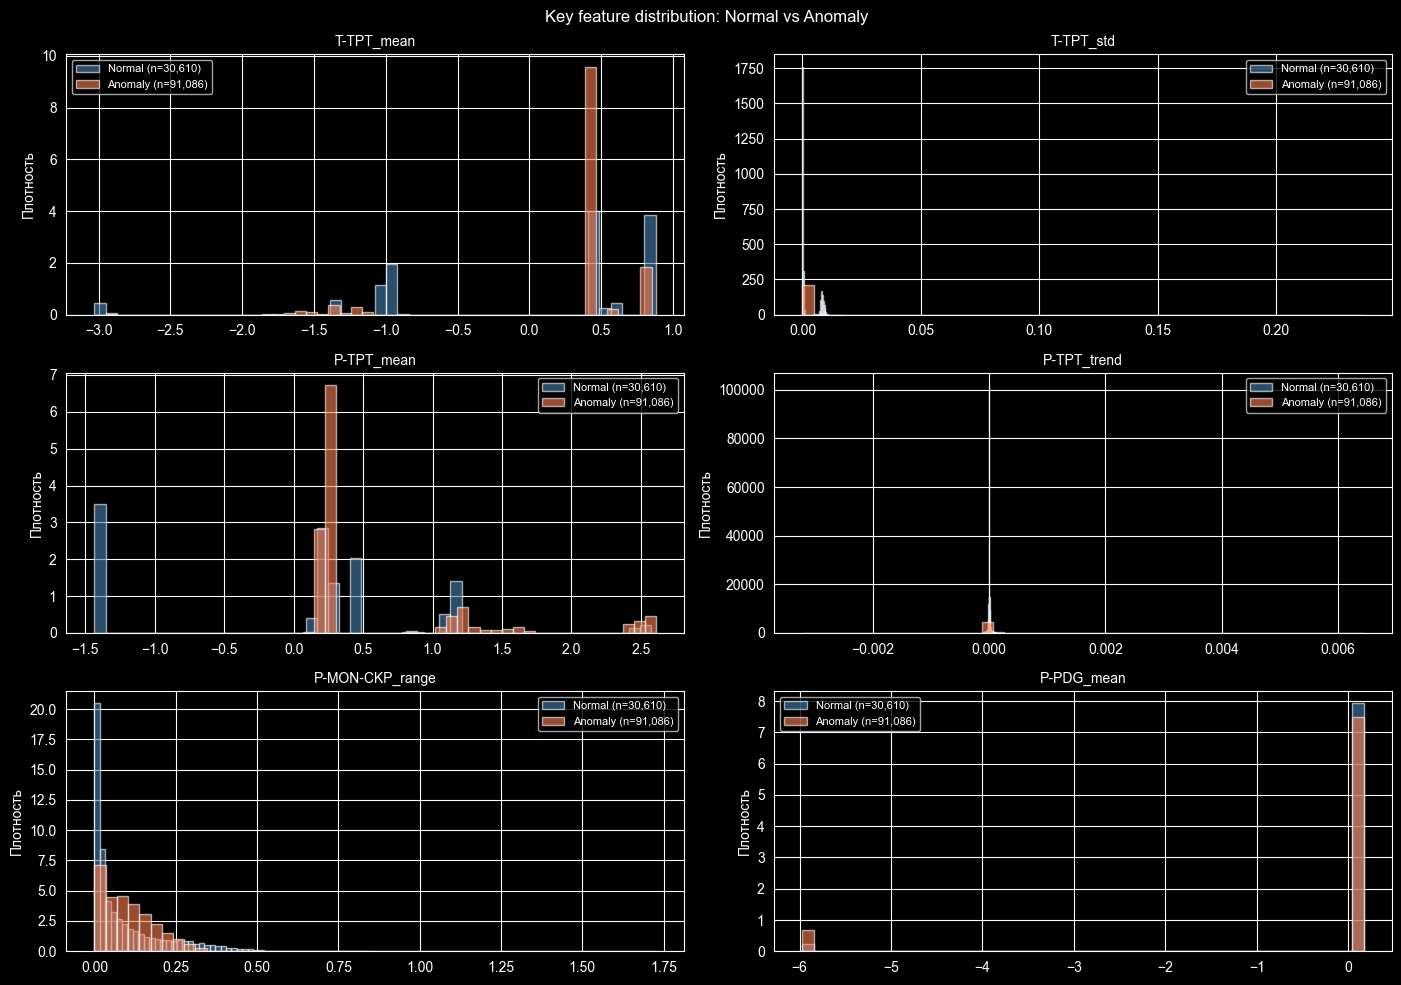

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

key_features = [
    "T-TPT_mean", "T-TPT_std",
    "P-TPT_mean", "P-TPT_trend",
    "P-MON-CKP_range", "P-PDG_mean"
]

for ax, feat in zip(axes, key_features):
    if feat not in df_features.columns:
        ax.set_visible(False)
        continue

    normal = df_features[df_features["label"] == 0][feat]
    anomaly = df_features[df_features["label"] == 1][feat]

    ax.hist(normal, bins=50, alpha=0.6, color="steelblue",
            label=f"Normal (n={len(normal):,})", density=True)
    ax.hist(anomaly, bins=50, alpha=0.6, color="coral",
            label=f"Anomaly (n={len(anomaly):,})", density=True)
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_ylabel("Плотность")

plt.suptitle("Key feature distribution: Normal vs Anomaly", fontsize=12)
plt.tight_layout()
plt.savefig("../outputs/figures/feature_distributions.png", dpi=150)
plt.show()

In [6]:
FEATURES_PATH = "../outputs/features.parquet"
df_features.to_parquet(FEATURES_PATH, index=False)

size_mb = Path(FEATURES_PATH).stat().st_size / 1024 / 1024
print(f"Features saved: {FEATURES_PATH}")
print(f"Soze: {size_mb:.1f} MB")
print(f"Total: {len(df_features):,} dataframes * {len(feature_cols)} features")

Features saved: ../outputs/features.parquet
Soze: 17.7 MB
Total: 121,696 dataframes * 31 features
